<a href="https://colab.research.google.com/github/giannismantzaris-cmd/DAMA61/blob/main/Mantzaris_WA5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [42]:
# increase the width of the notebook
from IPython.display import display, HTML
display(HTML("<style>.container { width:90% !important; }</style>"))

In [43]:
#All needed imports
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

Problem 1

In [ ]:
from tensorflow.keras.datasets import cifar10
(x_train_full, y_train_full), (x_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
print("Original training set shape:", x_train_full.shape, y_train_full.shape)
print("Original test set shape:    ", x_test.shape, y_test.shape)

Original training set shape: (50000, 32, 32, 3) (50000, 1)
Original test set shape:     (10000, 32, 32, 3) (10000, 1)


In [ ]:
# Normalize the pixel values to [0, 1]
x_train_full = x_train_full.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

In [ ]:
# Combine train and test to split as 60/20/20
X = np.concatenate([x_train_full, x_test], axis=0)
y = np.concatenate([y_train_full, y_test], axis=0)
print("Full dataset:", X.shape, y.shape)

Full dataset: (60000, 32, 32, 3) (60000, 1)


In [ ]:
# Shuffle
np.random.seed(42)
indices = np.random.permutation(len(X))
X = X[indices]
y = y[indices]

In [ ]:
# Split the full dateset to: 60% / 20% / 20%
n_total = len(X)  # 60000
n_train = int(0.6 * n_total)  # 36000
n_valid_and_test = int(0.2 * n_total)  # 12000

X_train = X[:n_train]
y_train = y[:n_train]

X_valid = X[n_train:n_train + n_valid_and_test]
y_valid = y[n_train:n_train + n_valid_and_test]

X_test = X[n_train + n_valid_and_test:]
y_test = y[n_train + n_valid_and_test:]

In [ ]:
# Print shapes to verify
print("Training set:   ", X_train.shape, y_train.shape)
print("Validation set: ", X_valid.shape, y_valid.shape)
print("Test set:       ", X_test.shape, y_test.shape)

Training set:    (36000, 32, 32, 3) (36000, 1)
Validation set:  (12000, 32, 32, 3) (12000, 1)
Test set:        (12000, 32, 32, 3) (12000, 1)


In [ ]:
from tensorflow.keras.utils import to_categorical
num_classes = 10

# Convert to one-hot
y_train_oh = to_categorical(y_train, num_classes)
y_valid_oh   = to_categorical(y_valid, num_classes)
y_test_oh  = to_categorical(y_test, num_classes)

In [ ]:
print("y_train one-hot:", y_train_oh.shape)
print("y_val one-hot:", y_valid_oh.shape)
print("y_test one-hot:", y_test_oh.shape)

y_train one-hot: (36000, 10)
y_val one-hot: (12000, 10)
y_test one-hot: (12000, 10)


In [ ]:
model = keras.Sequential([
    keras.Input(shape=(32, 32, 3)),
#first layer
    layers.Conv2D(filters=16, kernel_size=(5, 5), strides=2, padding="same", activation="relu"),
    layers.MaxPooling2D(pool_size=(2, 2)),
#second layer - retain omage size by adding padding zeros
    layers.Conv2D(filters=32, kernel_size=(3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D(pool_size=(2, 2)),
#third layer - retain imagr size by adding padding zeros
    layers.Conv2D(filters=64, kernel_size=(3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D(pool_size=(2, 2)),

#classification part
    layers.Flatten(),
    layers.Dropout(0.25),

    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(10, activation="softmax")
])

In [ ]:
#Create a clone model of the above CNN with exactly the same initial weights.

clone_model = keras.models.clone_model(model)
clone_model.build(input_shape=(None, 32, 32, 3))

# copy same weights
clone_model.set_weights(model.get_weights())

In [ ]:
# Early stopping Adam
early_stopping_adam = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [ ]:
# Early stopping SGD
early_stopping_sgd = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [ ]:
# Compile the original model with Adam
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
# Compile the clone model with SGD
clone_model.compile(
    optimizer="sgd",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
# Train model with Adam
history_adam = model.fit(
    X_train, y_train_oh,
    epochs=100,
    validation_data=(X_valid, y_valid_oh),
    callbacks=[early_stopping_adam],
    verbose=1
)

Epoch 1/100
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 20s 17ms/step - accuracy: 0.7140 - loss: 0.8077 - val_accuracy: 0.6375 - val_loss: 1.0589
Epoch 2/100
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 18s 16ms/step - accuracy: 0.7169 - loss: 0.7936 - val_accuracy: 0.6418 - val_loss: 1.0471
Epoch 3/100
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 19s 17ms/step - accuracy: 0.7201 - loss: 0.7850 - val_accuracy: 0.6420 - val_loss: 1.0472
Epoch 4/100
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 18s 16ms/step - accuracy: 0.7219 - loss: 0.7781 - val_accuracy: 0.6295 - val_loss: 1.0891
Epoch 5/100
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 18s 16ms/step - accuracy: 0.7272 - loss: 0.7681 - val_accuracy: 0.6408 - val_loss: 1.0647
Epoch 6/100
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 20s 15ms/step - accuracy: 0.7284 - loss: 0.7607 - val_accuracy: 0.6483 - val_loss: 1.0265
Epoch 7/100
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 23s 17ms/step - accuracy: 0.7347 - loss: 0.7466 - val_accuracy: 0.6466 - val_loss: 1.0491
Epoch 8/100
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 18s 16ms/step - accuracy: 

In [ ]:
# Train model with SGD
history_sgd = clone_model.fit(
    X_train, y_train_oh,
    epochs=100,
    validation_data=(X_valid, y_valid_oh),
    callbacks=[early_stopping_sgd],
    verbose=1
)

Epoch 1/100
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 21s 18ms/step - accuracy: 0.7126 - loss: 0.8073 - val_accuracy: 0.6482 - val_loss: 1.0287
Epoch 2/100
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 19s 16ms/step - accuracy: 0.7175 - loss: 0.7939 - val_accuracy: 0.6503 - val_loss: 1.0280
Epoch 3/100
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 19s 17ms/step - accuracy: 0.7199 - loss: 0.7847 - val_accuracy: 0.6332 - val_loss: 1.0764
Epoch 4/100
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 18s 16ms/step - accuracy: 0.7214 - loss: 0.7756 - val_accuracy: 0.6317 - val_loss: 1.0918
Epoch 5/100
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 18s 16ms/step - accuracy: 0.7283 - loss: 0.7578 - val_accuracy: 0.6515 - val_loss: 1.0385
Epoch 6/100
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - accuracy: 0.7297 - loss: 0.7547 - val_accuracy: 0.6463 - val_loss: 1.0467
Epoch 7/100
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 19s 17ms/step - accuracy: 0.7332 - loss: 0.7476 - val_accuracy: 0.6437 - val_loss: 1.0667


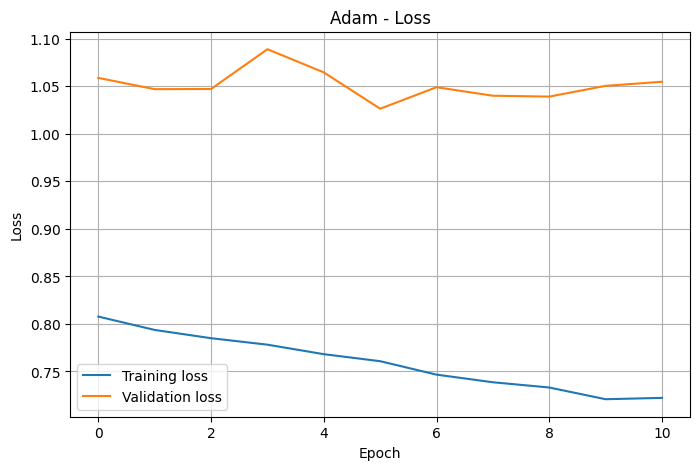

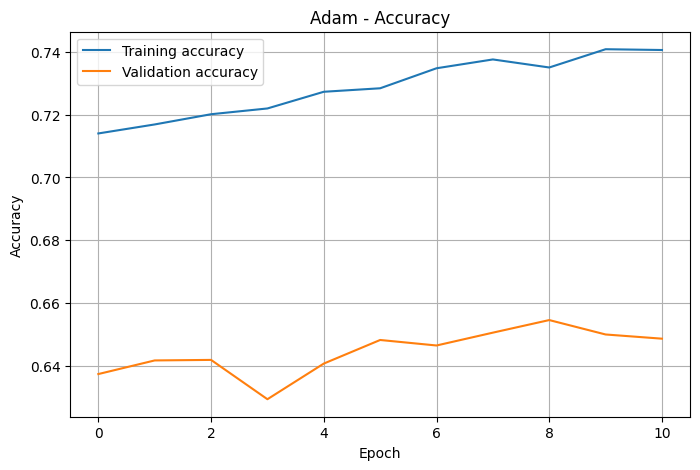

In [ ]:
# Adam
plt.figure(figsize=(8, 5))
plt.plot(history_adam.history["loss"], label="Training loss")
plt.plot(history_adam.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Adam - Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_adam.history["accuracy"], label="Training accuracy")
plt.plot(history_adam.history["val_accuracy"], label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Adam - Accuracy")
plt.legend()
plt.grid(True)
plt.show()



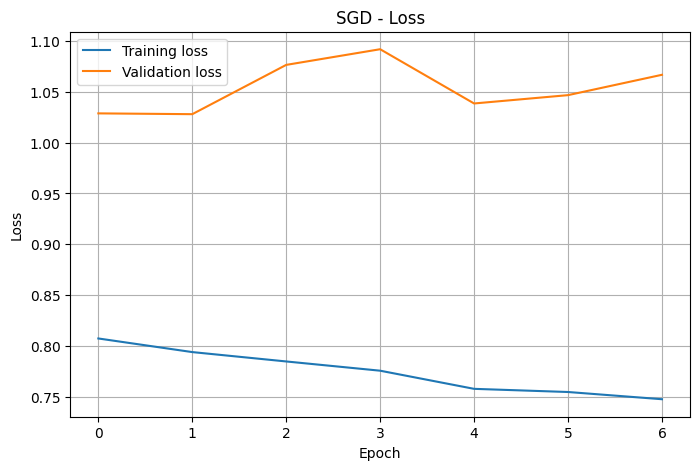

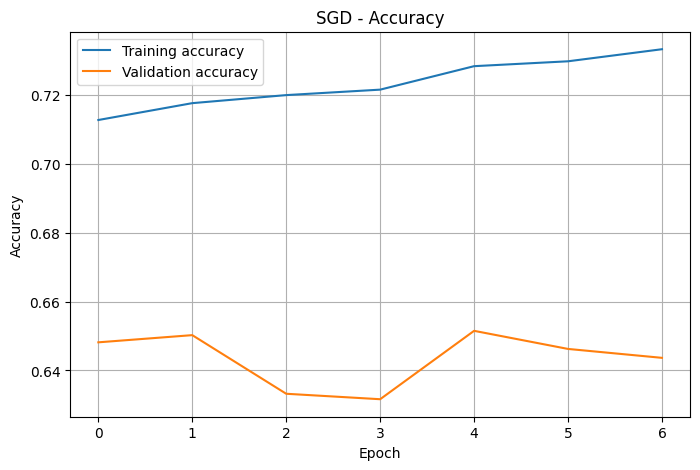

In [ ]:
# SGD
plt.figure(figsize=(8, 5))
plt.plot(history_sgd.history["loss"], label="Training loss")
plt.plot(history_sgd.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("SGD - Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_sgd.history["accuracy"], label="Training accuracy")
plt.plot(history_sgd.history["val_accuracy"], label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("SGD - Accuracy")
plt.legend()
plt.grid(True)
plt.show()

Both optimizers perform well, with decreasing loss and increasing accuracy. Adam achieves slightly better performance and continues improving for more epochs, while SGD stops earlier due to earlier validation plateau. Both models show mild overfitting, and early stopping prevents further degradation. Overall, performance is similar, with Adam slightly outperforming SGD.

In [ ]:
# Validate whick optimizer is best
best_val_acc_adam = max(history_adam.history["val_accuracy"])
best_val_acc_sgd  = max(history_sgd.history["val_accuracy"])


if best_val_acc_adam >= best_val_acc_sgd:
    best = "Adam"

else:
    best = "SGD"

print("Selected best model:",best)

Selected best model: Adam


In [ ]:
# Confusion matrix and accuracy on test set
test_loss, test_accuracy = model.evaluate(X_test, y_test_oh, verbose=0)
print("Test accuracy:", test_accuracy)

Test accuracy: 0.6527500152587891


In [ ]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


In [ ]:
y_true = y_test.flatten()  # convert from (n,1) to (n,)

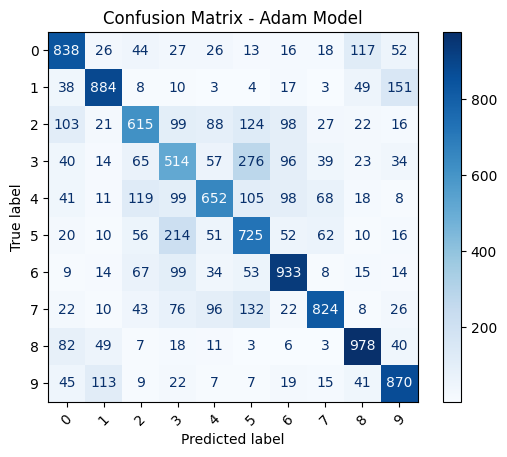

In [ ]:
cm = confusion_matrix(y_true, y_pred_classes)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix - Adam Model")
plt.show()

Problem 2

In [74]:
# Load the dataset
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv"
temps = pd.read_csv(url, parse_dates=["Date"])

In [75]:
temps.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3650 entries, 0 to 3649
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    3650 non-null   datetime64[ns]
 1   Temp    3650 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 57.2 KB


In [76]:
# Inspect the dataset
print("Shape of dataset:", temps.shape)
print("\nFirst 5 rows:")
print(temps.head())

print("\nLast 5 rows:")
print(temps.tail())

print("\nData types:")
print(temps.dtypes)

print("\nMissing values:")
print(temps.isna().sum())

Shape of dataset: (3650, 2)

First 5 rows:
        Date  Temp
0 1981-01-01  20.7
1 1981-01-02  17.9
2 1981-01-03  18.8
3 1981-01-04  14.6
4 1981-01-05  15.8

Last 5 rows:
           Date  Temp
3645 1990-12-27  14.0
3646 1990-12-28  13.6
3647 1990-12-29  13.5
3648 1990-12-30  15.7
3649 1990-12-31  13.0

Data types:
Date    datetime64[ns]
Temp           float64
dtype: object

Missing values:
Date    0
Temp    0
dtype: int64


In [77]:
# Descriptive statistics
temps.describe()

,Date,Temp
count,3650,3650.000000
mean,1985-12-31 07:12:00,11.177753
min,1981-01-01 00:00:00,0.000000
25%,1983-07-02 06:00:00,8.300000
50%,1985-12-31 12:00:00,11.000000
75%,1988-06-30 18:00:00,14.000000
max,1990-12-31 00:00:00,26.300000
std,NaN,4.071837


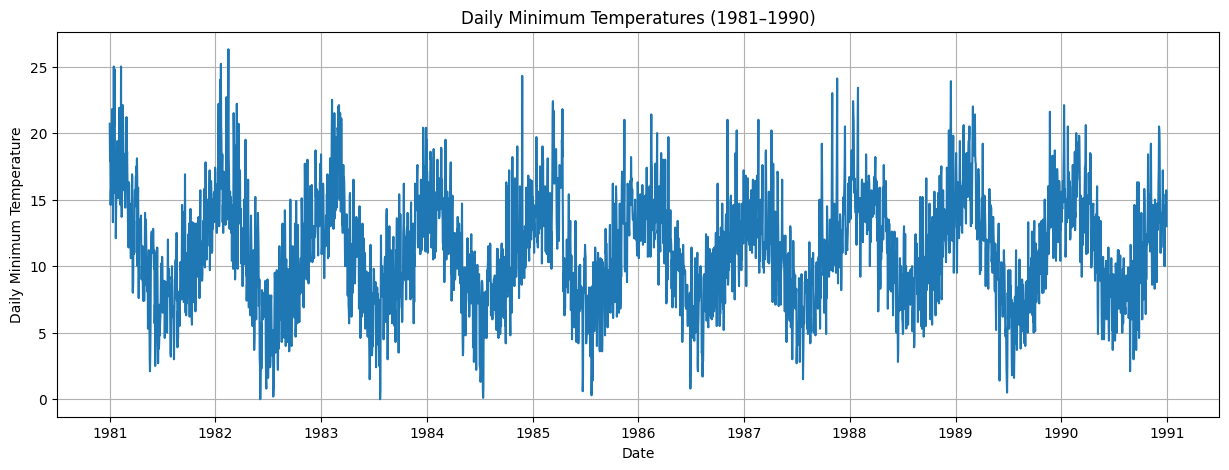

In [78]:
# Plot the entire dataset
plt.figure(figsize=(15, 5))
plt.plot(temps["Date"], temps["Temp"])
plt.xlabel("Date")
plt.ylabel("Daily Minimum Temperature")
plt.title("Daily Minimum Temperatures (1981–1990)")
plt.grid(True)
plt.show()

In [79]:
# Keep only the temperature values and convert to 2d for scaler
data = temps["Temp"].values.reshape(-1, 1)

In [80]:
# Split
n = len(data)
train_end = int(0.70 * n)
val_end = int(0.85 * n)

# Chronological split
train = data[:train_end]
val = data[train_end:val_end]
test = data[val_end:]

print("Train shape:", train.shape)
print("Validation shape:", val.shape)
print("Test shape:", test.shape)

Train shape: (2555, 1)
Validation shape: (547, 1)
Test shape: (548, 1)


In [81]:
# Standardization
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train)
val_scaled = scaler.transform(val)
test_scaled = scaler.transform(test)

In [82]:
# Define the function and create lists to store inputs and outputs
def to_windows(series, input_length=30, output_length=7):
    X = []
    y = []

#create windows with 30 inputs and 7 outputs by shifting each window by 1 day ensuring we make full windows (size 37)
#which overlap as much as possible to give
    for i in range(len(series) - input_length - output_length + 1):
        window = series[i : i + input_length + output_length]
        X.append(window[:input_length])
        y.append(window[input_length:, 0])   # i take the single feature column. I did this after having trouble in next question,
                                             #I understand i need a 2D output to match the Dense layer output.

    return np.array(X), np.array(y)



In [83]:
# Create the training, validation and test windows
X_train, y_train = to_windows(train_scaled, 30, 7)
X_val, y_val = to_windows(val_scaled, 30, 7)
X_test, y_test = to_windows(test_scaled, 30, 7)

# Verify the windowing was performed accurately keeping the correct split (70, 15 ,15)
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)



X_train shape: (2519, 30, 1)
y_train shape: (2519, 7)
X_val shape: (511, 30, 1)
y_val shape: (511, 7)
X_test shape: (512, 30, 1)
y_test shape: (512, 7)


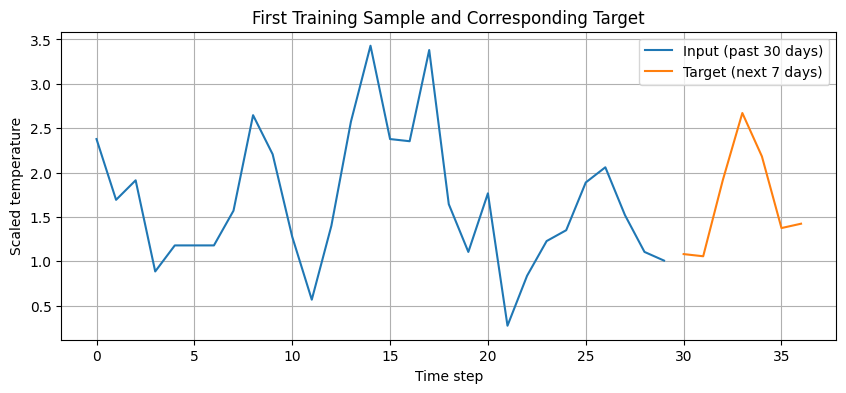

In [84]:
# Visualize the first training sample and its corresponding target
plt.figure(figsize=(10, 4))

plt.plot(range(30), X_train[0].flatten(), label="Input (past 30 days)")
plt.plot(range(30, 37), y_train[0].flatten(), label="Target (next 7 days)")

plt.xlabel("Time step")
plt.ylabel("Scaled temperature")
plt.title("First Training Sample and Corresponding Target")
plt.legend()
plt.grid(True)
plt.show()

In [85]:
# Build the Simple RNN model
model = keras.Sequential([
    keras.Input(shape=(30, 1)),
    keras.layers.SimpleRNN(32, return_sequences=True),
    keras.layers.SimpleRNN(32, return_sequences=True),
    keras.layers.SimpleRNN(32),
    keras.layers.Dense(7)
])

# Compile the model
model.compile(
    optimizer="adam",
    loss=keras.losses.Huber(),
    metrics=["mae"]
)

# Early stopping
early_stopping = keras.callbacks.EarlyStopping(
    patience=5,
    restore_best_weights=True
)

In [86]:
# Train the model
history = model.fit(
    X_train, y_train,
    epochs=100,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - loss: 0.2731 - mae: 0.6065 - val_loss: 0.2358 - val_mae: 0.5592
Epoch 2/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.2402 - mae: 0.5625 - val_loss: 0.2267 - val_mae: 0.5462
Epoch 3/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.2351 - mae: 0.5561 - val_loss: 0.2242 - val_mae: 0.5424
Epoch 4/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.2323 - mae: 0.5526 - val_loss: 0.2235 - val_mae: 0.5410
Epoch 5/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.2304 - mae: 0.5501 - val_loss: 0.2235 - val_mae: 0.5408
Epoch 6/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.2288 - mae: 0.5481 - val_loss: 0.2235 - val_mae: 0.5406
Epoch 7/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.2274 - mae: 0.5462 - val_loss: 0.2235 - val_mae: 0.5406
Epoch 8/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 0.2260 - mae: 0.5446 - val_loss: 0.2235 - val_mae: 0.5406
Epoch 9/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - lo

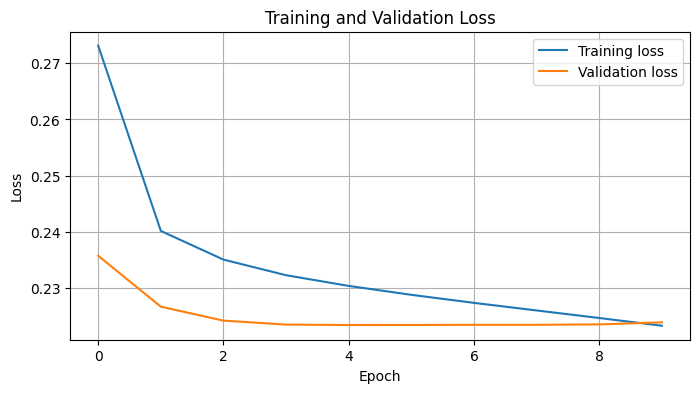

In [87]:
# Plot training and validation loss
plt.figure(figsize=(8, 4))
plt.plot(history.history["loss"], label="Training loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

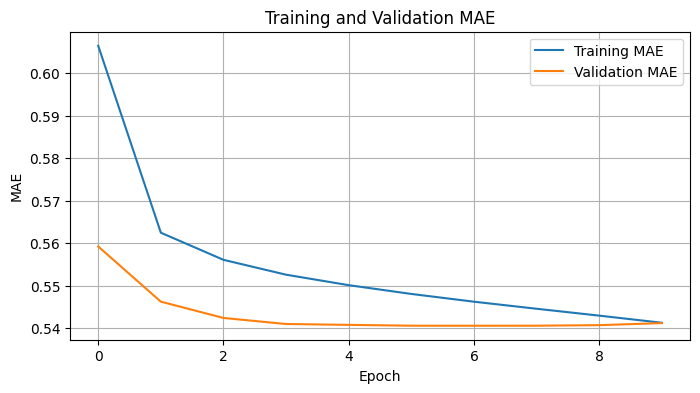

In [88]:
# Plot training and validation MAE
plt.figure(figsize=(8, 4))
plt.plot(history.history["mae"], label="Training MAE")
plt.plot(history.history["val_mae"], label="Validation MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.title("Training and Validation MAE")
plt.legend()
plt.grid(True)
plt.show()

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


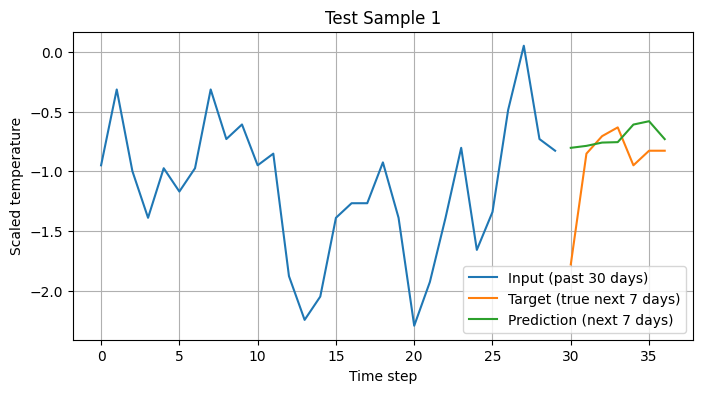

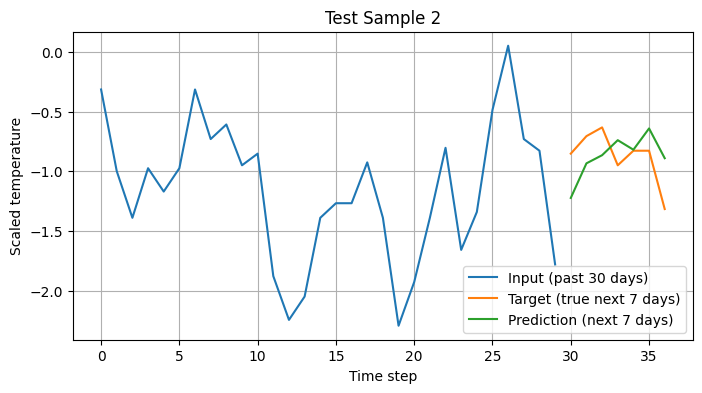

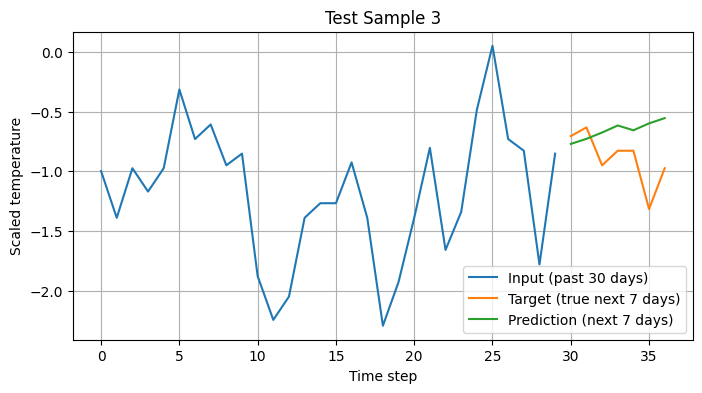

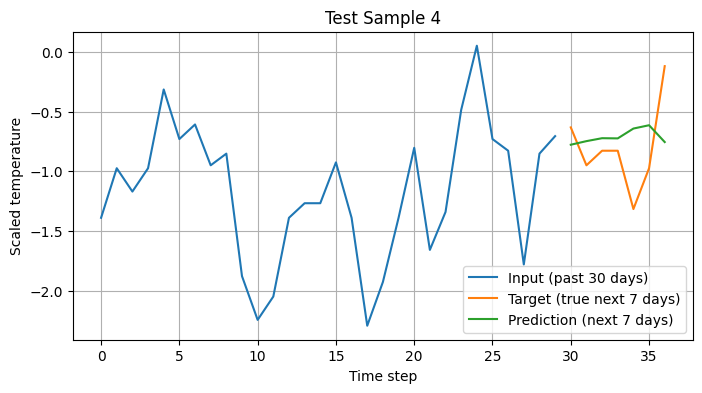

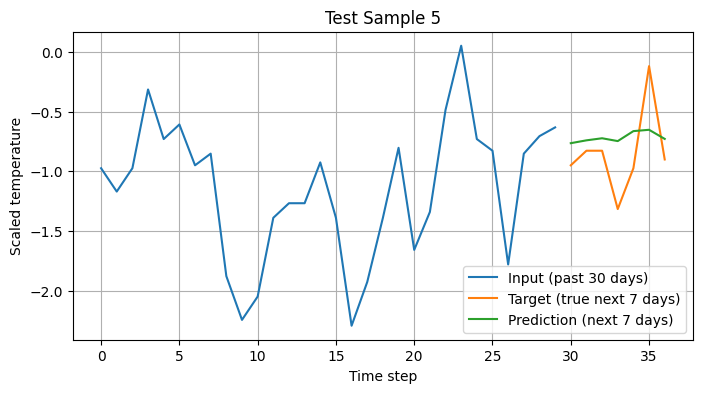

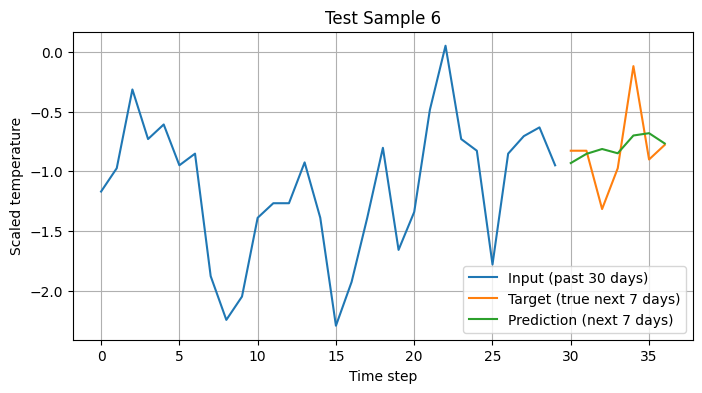

In [89]:
# Predict on the test set
y_pred = model.predict(X_test)

# Plot inputs, true targets, and predictions for the first 6 test samples
for i in range(6):
    plt.figure(figsize=(8, 4))
    plt.plot(range(30), X_test[i].flatten(), label="Input (past 30 days)")
    plt.plot(range(30, 37), y_test[i], label="Target (true next 7 days)")
    plt.plot(range(30, 37), y_pred[i], label="Prediction (next 7 days)")
    plt.xlabel("Time step")
    plt.ylabel("Scaled temperature")
    plt.title(f"Test Sample {i+1}")
    plt.legend()
    plt.grid(True)
    plt.show()

In [90]:
# Reshape to 2D for inverse_transform
y_test_reshaped = y_test.reshape(-1, 1)
y_pred_reshaped = y_pred.reshape(-1, 1)

# Inverse transform
y_test_original = scaler.inverse_transform(y_test_reshaped)
y_pred_original = scaler.inverse_transform(y_pred_reshaped)

# Reshape back to (samples, 7)
y_test_original = y_test_original.reshape(y_test.shape)
y_pred_original = y_pred_original.reshape(y_pred.shape)

# Compute metrics in original scale
test_mae_original = mean_absolute_error(
    y_test_original.flatten(),
    y_pred_original.flatten()
)

test_rmse_original = np.sqrt(mean_squared_error(
    y_test_original.flatten(),
    y_pred_original.flatten()
))

print("Test MAE (original scale):", test_mae_original)
print("Test RMSE (original scale):", test_rmse_original)

Test MAE (original scale): 1.9962656041341167
Test RMSE (original scale): 2.578659737576172


In [91]:
# Prepare the three splits for sequence to sequence forecasting
#with the same number of previous days and days ahead.

def to_seq2seq_windows(series, input_length=30, output_length=7):
    X = []
    y = []

    for i in range(len(series) - input_length - output_length + 1):
        X.append(series[i:i + input_length])
        y.append(series[i + input_length:i + input_length + output_length])  # now I keep the sequence output

    return np.array(X), np.array(y)

In [92]:
X_train_seq, y_train_seq = to_seq2seq_windows(train_scaled, 30, 7)
X_val_seq, y_val_seq = to_seq2seq_windows(val_scaled, 30, 7)
X_test_seq, y_test_seq = to_seq2seq_windows(test_scaled, 30, 7)

print("X_train_seq shape:", X_train_seq.shape)
print("y_train_seq shape:", y_train_seq.shape)
print("X_val_seq shape:", X_val_seq.shape)
print("y_val_seq shape:", y_val_seq.shape)
print("X_test_seq shape:", X_test_seq.shape)
print("y_test_seq shape:", y_test_seq.shape)

X_train_seq shape: (2519, 30, 1)
y_train_seq shape: (2519, 7, 1)
X_val_seq shape: (511, 30, 1)
y_val_seq shape: (511, 7, 1)
X_test_seq shape: (512, 30, 1)
y_test_seq shape: (512, 7, 1)


In [93]:
# Utilize batches of 16 samples and avoid shuffling.

batch_size = 16

train_ds = tf.data.Dataset.from_tensor_slices((X_train_seq, y_train_seq)).batch(batch_size)
val_ds = tf.data.Dataset.from_tensor_slices((X_val_seq, y_val_seq)).batch(batch_size)
test_ds = tf.data.Dataset.from_tensor_slices((X_test_seq, y_test_seq)).batch(batch_size)

In [94]:
# Build the Gated Recurrent Unit model

model_gru = keras.Sequential([
    keras.Input(shape=(30, 1)),
    keras.layers.GRU(32, return_sequences=True),
    keras.layers.GRU(32),
    keras.layers.RepeatVector(7),
    keras.layers.GRU(32, return_sequences=True),
    keras.layers.TimeDistributed(keras.layers.Dense(1))
])

# Complile the model
model_gru.compile(
    optimizer="adam",
    loss=keras.losses.Huber(),
    metrics=["mae"]
)

# Introduce early stopping
early_stopping = keras.callbacks.EarlyStopping(
    patience=5,
    restore_best_weights=True
)

# Train the model
history_gru = model_gru.fit(
    train_ds,
    epochs=100,
    validation_data=val_ds,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100
158/158 ━━━━━━━━━━━━━━━━━━━━ 12s 34ms/step - loss: 0.2611 - mae: 0.5906 - val_loss: 0.2449 - val_mae: 0.5722
Epoch 2/100
158/158 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - loss: 0.2428 - mae: 0.5666 - val_loss: 0.2387 - val_mae: 0.5632
Epoch 3/100
158/158 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - loss: 0.2399 - mae: 0.5625 - val_loss: 0.2352 - val_mae: 0.5581
Epoch 4/100
158/158 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - loss: 0.2378 - mae: 0.5595 - val_loss: 0.2304 - val_mae: 0.5509
Epoch 5/100
158/158 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - loss: 0.2359 - mae: 0.5569 - val_loss: 0.2265 - val_mae: 0.5452
Epoch 6/100
158/158 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - loss: 0.2341 - mae: 0.5544 - val_loss: 0.2235 - val_mae: 0.5408
Epoch 7/100
158/158 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - loss: 0.2325 - mae: 0.5521 - val_loss: 0.2214 - val_mae: 0.5375
Epoch 8/100
158/158 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - loss: 0.2311 - mae: 0.5500 - val_loss: 0.2199 - val_mae: 0.5354
Epoch 9/100
158/158 ━━━━━━━━━━━━━━━━━━

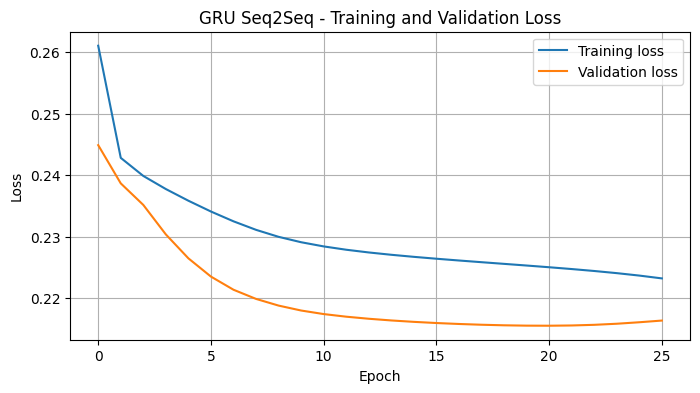

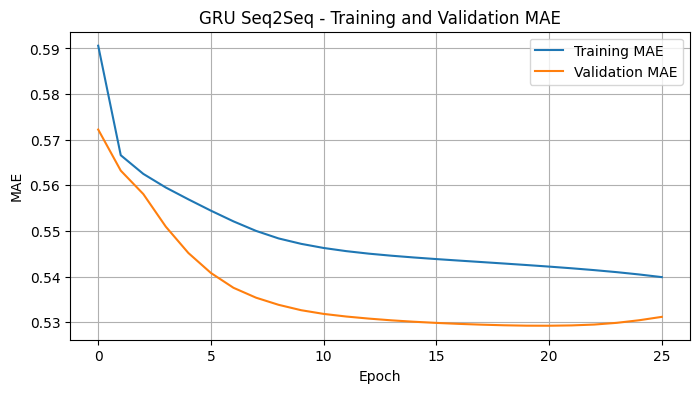

In [95]:
plt.figure(figsize=(8, 4))
plt.plot(history_gru.history["loss"], label="Training loss")
plt.plot(history_gru.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GRU Seq2Seq - Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(history_gru.history["mae"], label="Training MAE")
plt.plot(history_gru.history["val_mae"], label="Validation MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.title("GRU Seq2Seq - Training and Validation MAE")
plt.legend()
plt.grid(True)
plt.show()

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
y_pred_seq shape: (512, 7, 1)


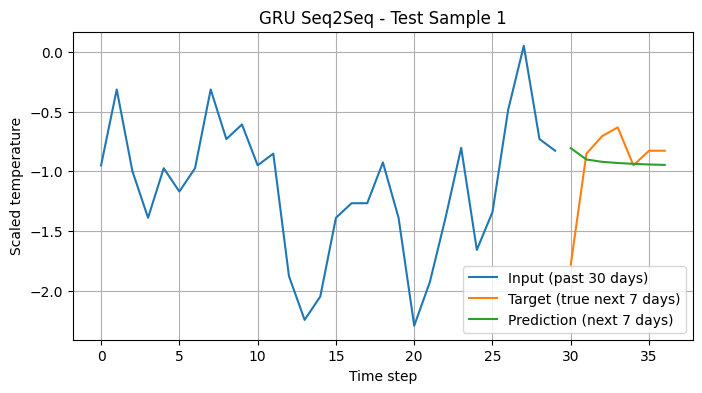

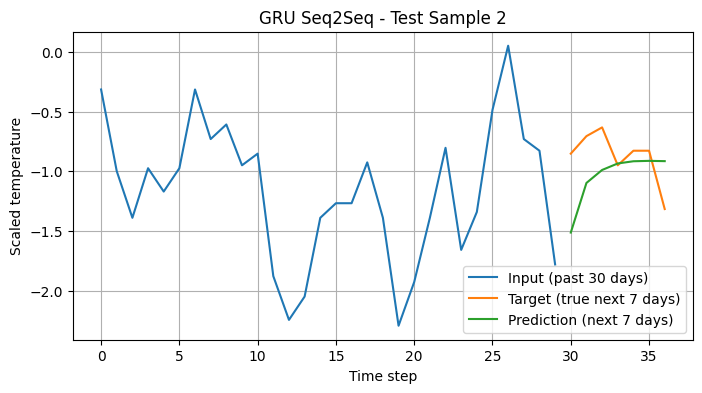

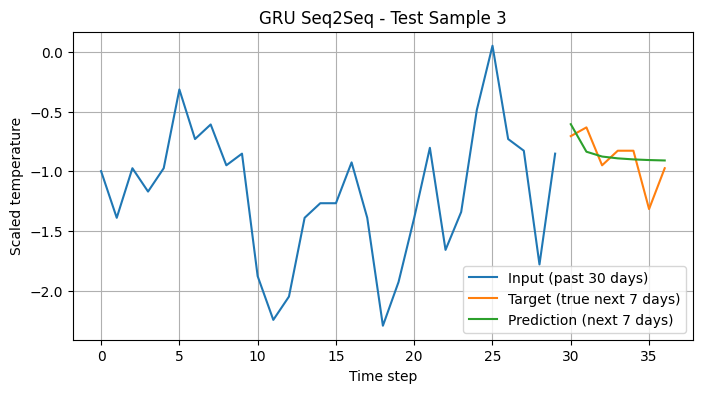

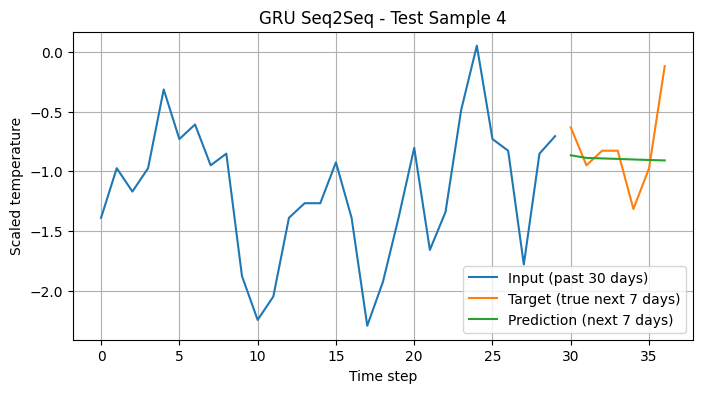

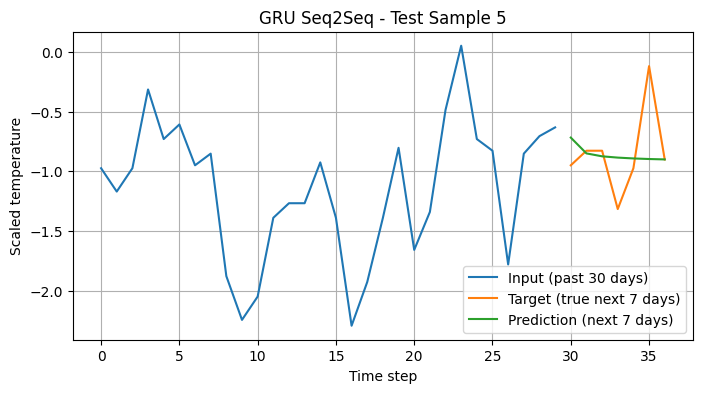

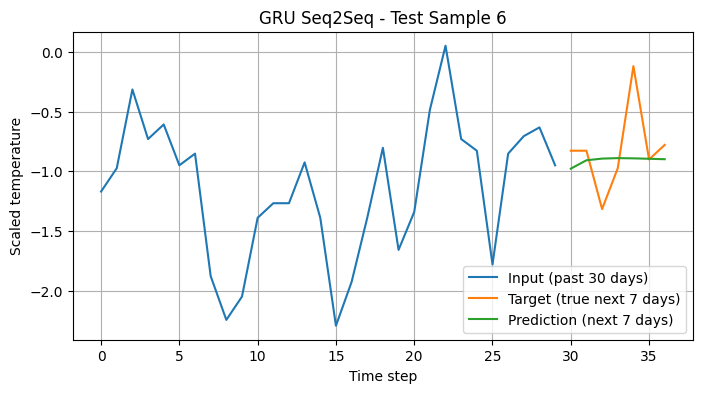

In [97]:
# Predict on test data
y_pred_seq = model_gru.predict(test_ds)

print("y_pred_seq shape:", y_pred_seq.shape)

# Plot first 6 test samples
for i in range(6):
    plt.figure(figsize=(8, 4))
    plt.plot(range(30), X_test_seq[i].flatten(), label="Input (past 30 days)")
    plt.plot(range(30, 37), y_test_seq[i].flatten(), label="Target (true next 7 days)")
    plt.plot(range(30, 37), y_pred_seq[i].flatten(), label="Prediction (next 7 days)")
    plt.xlabel("Time step")
    plt.ylabel("Scaled temperature")
    plt.title(f"GRU Seq2Seq - Test Sample {i+1}")
    plt.legend()
    plt.grid(True)
    plt.show()


In [99]:
# reshape to 2D for inverse_transform
y_test_seq_2d = y_test_seq.reshape(-1, 1)
y_pred_seq_2d = y_pred_seq.reshape(-1, 1)

# inverse transform to original scale
y_test_seq_original = scaler.inverse_transform(y_test_seq_2d)
y_pred_seq_original = scaler.inverse_transform(y_pred_seq_2d)

# reshape back
y_test_seq_original = y_test_seq_original.reshape(y_test_seq.shape)
y_pred_seq_original = y_pred_seq_original.reshape(y_pred_seq.shape)

# compute metrics
test_mae_gru = mean_absolute_error(
    y_test_seq_original.flatten(),
    y_pred_seq_original.flatten()
)

test_rmse_gru = np.sqrt(mean_squared_error(
    y_test_seq_original.flatten(),
    y_pred_seq_original.flatten()
))

print("GRU Seq2Seq - Test MAE (original scale):", test_mae_gru)
print("GRU Seq2Seq - Test RMSE (original scale):", test_rmse_gru)

GRU Seq2Seq - Test MAE (original scale): 1.9746098298047272
GRU Seq2Seq - Test RMSE (original scale): 2.555187623924211


In Q4, we used a SimpleRNN that takes the last 30 days and predicts the next 7 values all at once as a vector. This is simple but it does not really treat the output as a time sequence.

In Q5, we used a Gated Recurrent Unit with a sequence to sequence structure. The model predicts the 7 future days as a sequence, which is more appropriate for time series data. Also, Gated Recurrent Unit can handle temporal dependencies better than SimpleRNN.

The Gated Recurrent Unit sequence to sequence model performs slightly better (lower MAE and RMSE), but the difference is very small, so in fact there is no difference, despite the fact that in theory Q5 approach suits the problem better. This is probably because the dataset is quite smooth and predictable, so even the simpler model works well.